In [29]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [30]:
batch_size = 200
epochs = 2000
z_dim = 100

In [31]:
# Noise for visualization
z_vis = tf.random.normal([10, z_dim])
y_vis = tf.constant(np.eye(10), dtype='float32')

In [32]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train / 255.0
y_train = tf.one_hot(y_train, depth=10, dtype='float32')
data_iter = iter(tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(4 * batch_size).batch(batch_size).repeat())

In [33]:
# Models
# Generator
def Generator():
    z = tf.keras.layers.Input(shape=(z_dim,))
    y = tf.keras.layers.Input(shape=(10,))

    x = tf.keras.layers.Concatenate()([z, y])
    x = tf.keras.layers.Dense(3 * 3 * 512)(x)
    x = tf.keras.layers.Reshape((3, 3, 512))(x)

    x = tf.keras.layers.Conv2DTranspose(256, 3, 2, 'valid')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU()(x)

    x = tf.keras.layers.Conv2DTranspose(128, 4, 2, 'same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU()(x)

    x = tf.keras.layers.Conv2DTranspose(1, 4, 2, 'same', activation='sigmoid')(x)
    out = tf.keras.layers.Reshape((28, 28))(x)

    return tf.keras.Model(inputs=[z, y], outputs=out)

#Discriminator

def Discriminator():
    X = tf.keras.layers.Input(shape=(28, 28))
    Y = tf.keras.layers.Input(shape=(10,))

    y = tf.keras.layers.Reshape((1, 1, 10))(Y)
    y = tf.keras.layers.Lambda(lambda t: tf.tile(t, [1, 28, 28, 1]))(y)
    x = tf.keras.layers.Reshape((28, 28, 1))(X)
    x = tf.keras.layers.Concatenate()([x, y])

    x = tf.keras.layers.Conv2D(128, 4, 2, 'same')(x)

    x = tf.keras.layers.Conv2D(256, 4, 2, 'same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU()(x)

    x = tf.keras.layers.Conv2D(512, 4, 2, 'same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.LeakyReLU()(x)

    x = tf.keras.layers.Flatten()(x)
    out = tf.keras.layers.Dense(1)(x)

    return tf.keras.Model(inputs=[X, Y], outputs=out)


G = Generator()
D = Discriminator()


In [34]:
# Loss functions
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def G_loss(D, x_fake, y):
    return cross_entropy(tf.ones_like(D([x_fake, y], training=True)),
                         D([x_fake, y], training=True))

def D_loss(D, x_real, x_fake, y):
    real_loss = cross_entropy(tf.ones_like(D([x_real, y], training=True)),
                              D([x_real, y], training=True))
    fake_loss = cross_entropy(tf.zeros_like(D([x_fake, y], training=True)),
                              D([x_fake, y], training=True))
    return real_loss + fake_loss

In [35]:
# Optimizers
G_opt = tf.keras.optimizers.Adam(2e-4)
D_opt = tf.keras.optimizers.Adam(2e-4)

In [36]:
# ---- Metrics and Visualization ----
d_losses = []
g_losses = []

def visualize_images(generator, z, y, title="Generated Images"):
    generated_images = generator([z, y], training=False).numpy()
    plt.figure(figsize=(10, 2))
    for i in range(10):
        plt.subplot(1, 10, i + 1)
        plt.imshow(generated_images[i], cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

def plot_losses(d_losses, g_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(d_losses, label='Discriminator Loss')
    plt.plot(g_losses, label='Generator Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Curves')
    plt.legend()
    plt.grid(True)
    plt.show()

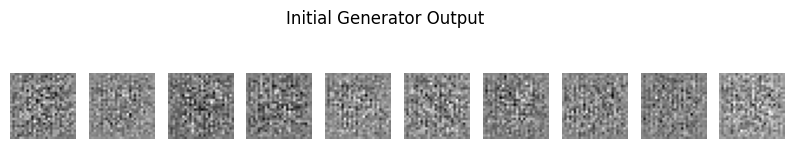

In [37]:
# ---- Initial Output Visualization ----
visualize_images(G, z_vis, y_vis, title="Initial Generator Output")

Epoch 0: D Loss = 1.8522, G Loss = 0.7728


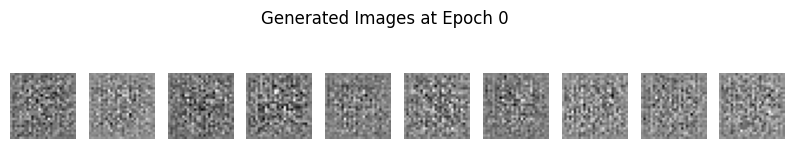

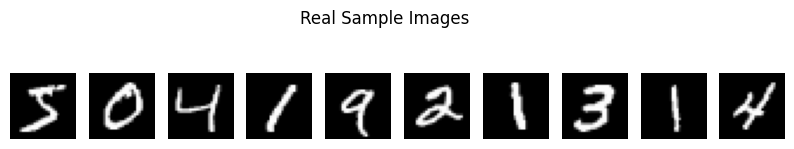

Epoch 100: D Loss = 0.0163, G Loss = 4.9812


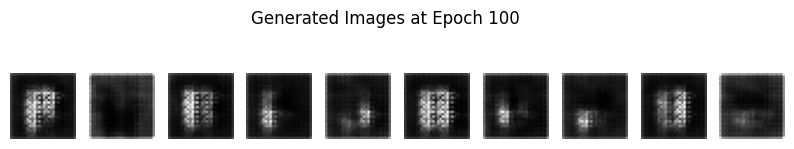

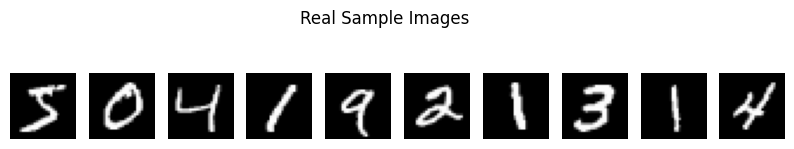

Epoch 200: D Loss = 0.2026, G Loss = 4.4901


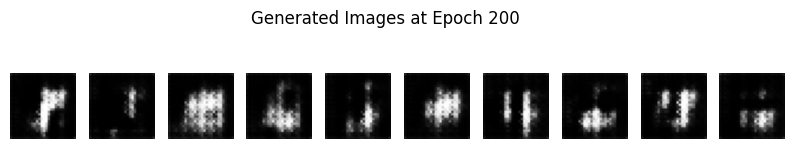

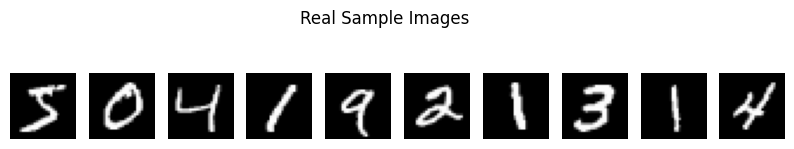

Epoch 300: D Loss = 0.3617, G Loss = 2.8215


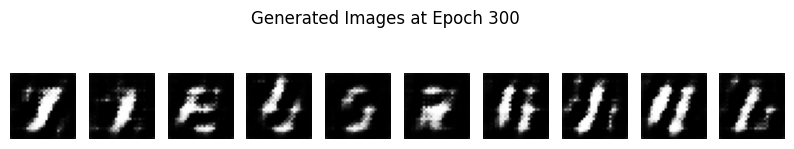

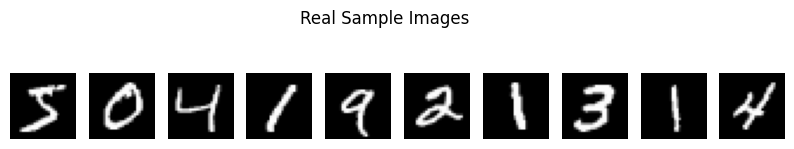

Epoch 400: D Loss = 0.1159, G Loss = 4.9439


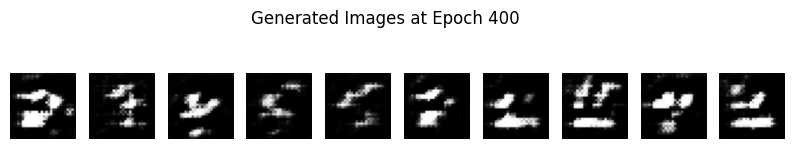

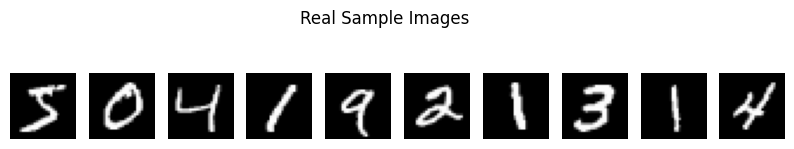

Epoch 500: D Loss = 0.1987, G Loss = 3.2649


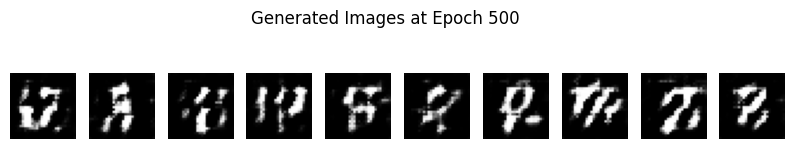

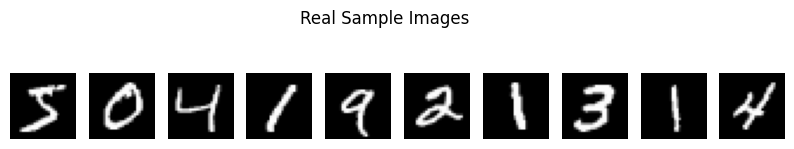

Epoch 600: D Loss = 0.0828, G Loss = 5.1120


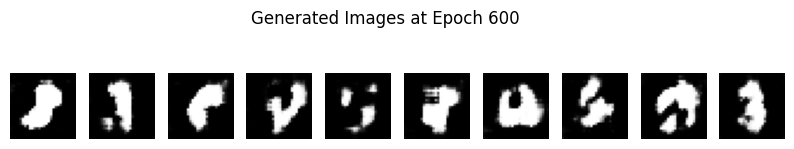

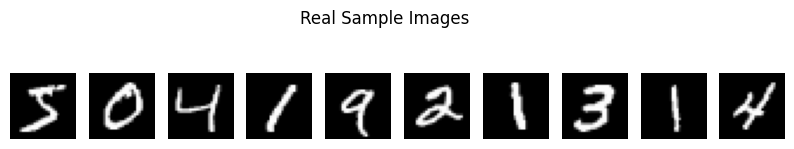

Epoch 700: D Loss = 0.7902, G Loss = 5.2692


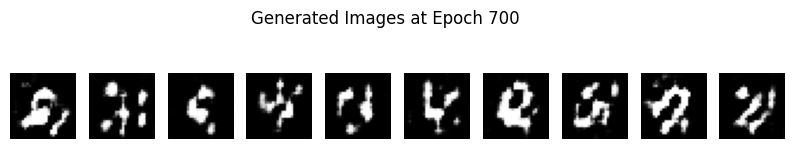

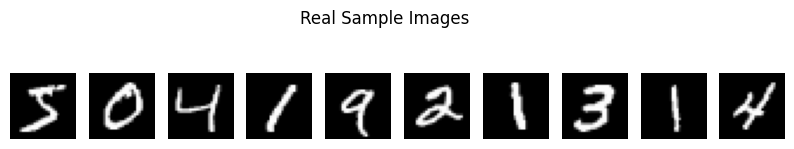

Epoch 800: D Loss = 0.1827, G Loss = 4.0746


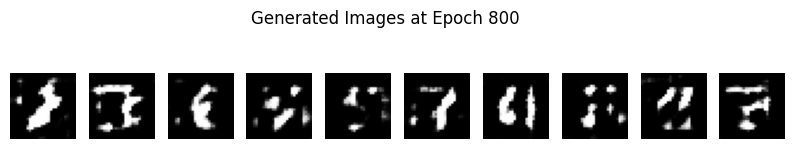

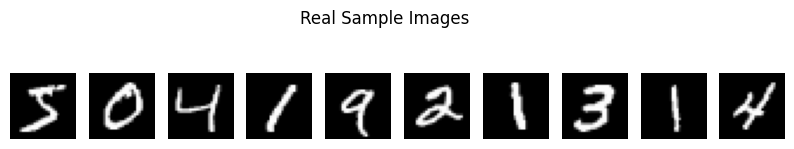

Epoch 900: D Loss = 0.4216, G Loss = 3.6384


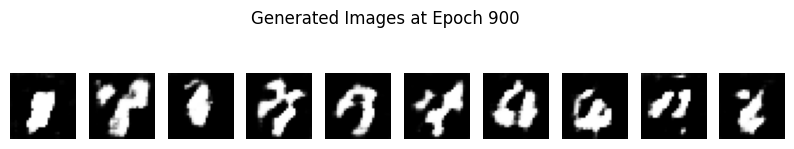

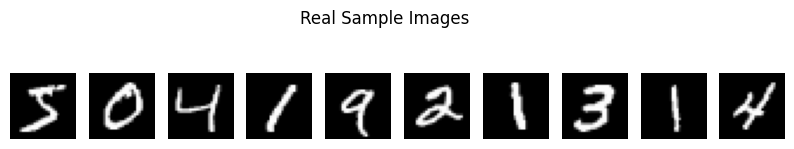

Epoch 1000: D Loss = 0.4867, G Loss = 1.4336


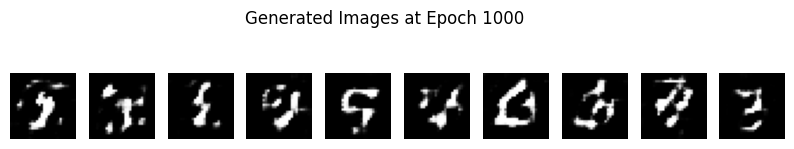

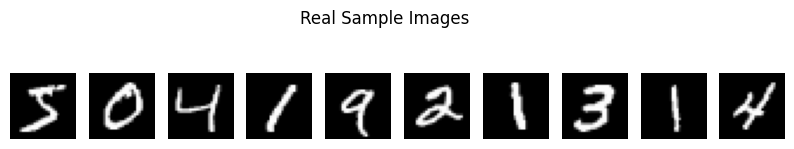

Epoch 1100: D Loss = 0.0591, G Loss = 4.1978


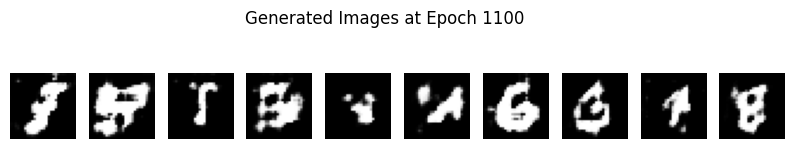

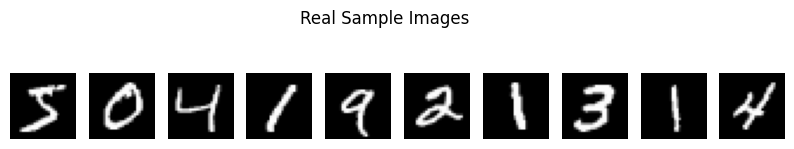

Epoch 1200: D Loss = 0.4594, G Loss = 2.6335


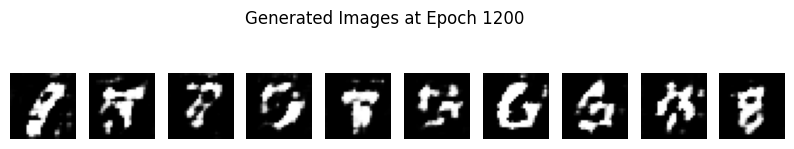

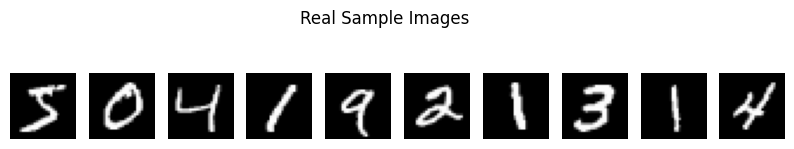

Epoch 1300: D Loss = 0.1699, G Loss = 4.1327


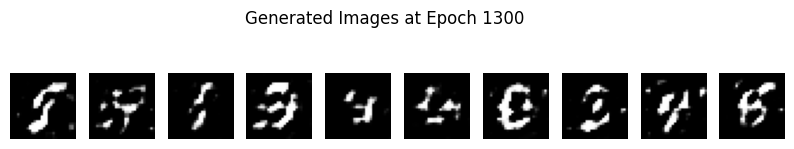

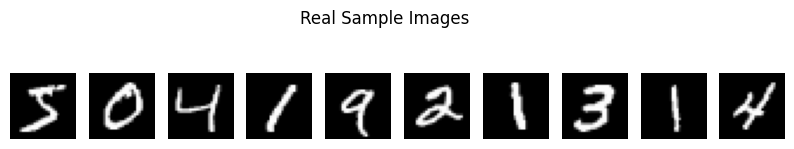

Epoch 1400: D Loss = 0.1663, G Loss = 3.9455


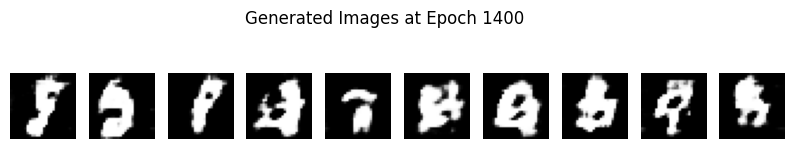

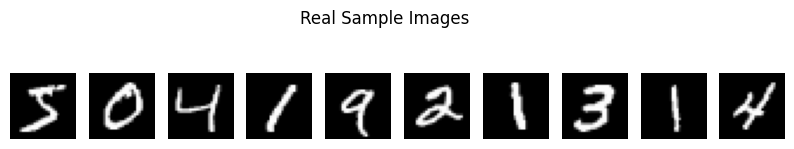

Epoch 1500: D Loss = 0.2948, G Loss = 3.1460


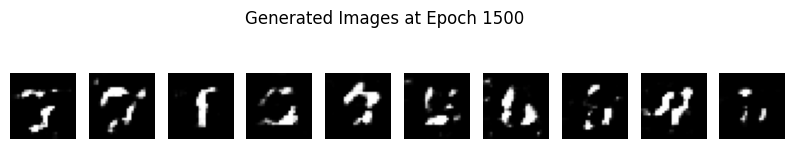

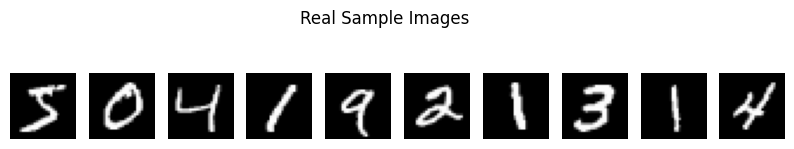

Epoch 1600: D Loss = 0.2412, G Loss = 3.0735


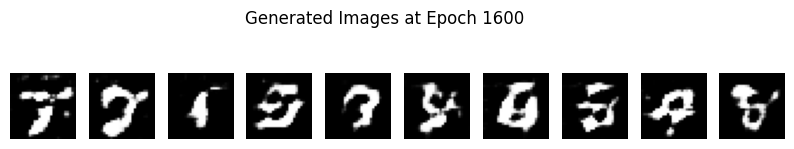

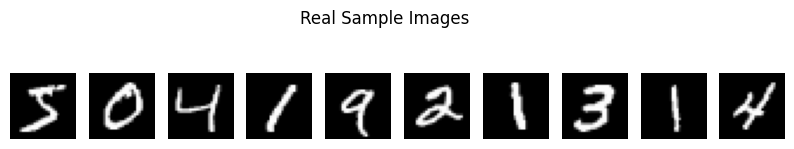

Epoch 1700: D Loss = 0.3215, G Loss = 3.0291


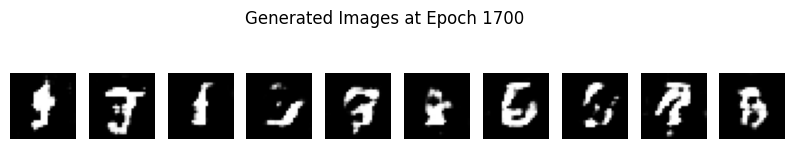

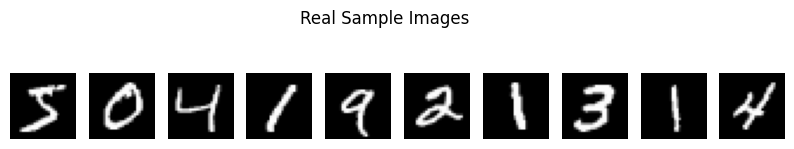

Epoch 1800: D Loss = 0.7160, G Loss = 1.4753


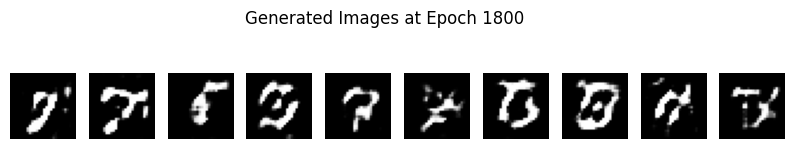

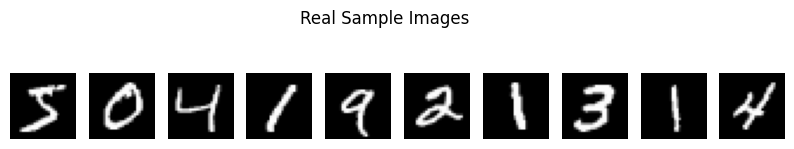

Epoch 1900: D Loss = 0.2587, G Loss = 2.3676


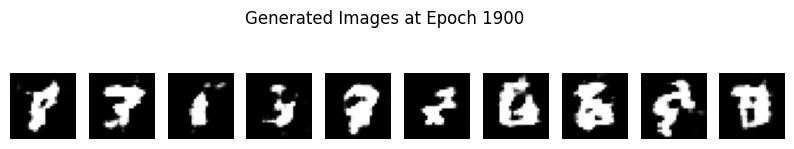

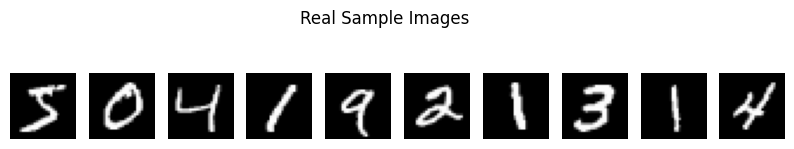

Epoch 2000: D Loss = 0.3467, G Loss = 2.4273


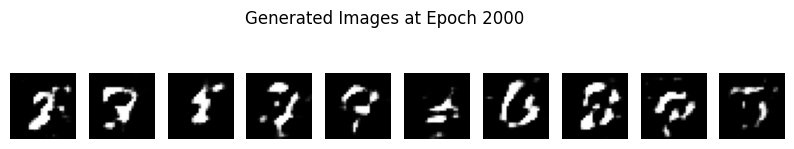

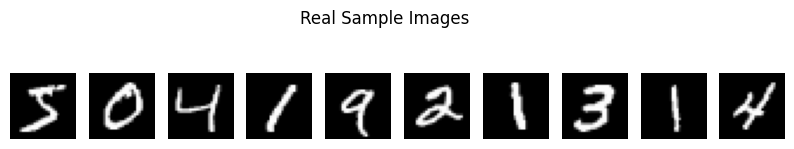

Epoch 2100: D Loss = 0.1824, G Loss = 2.7050


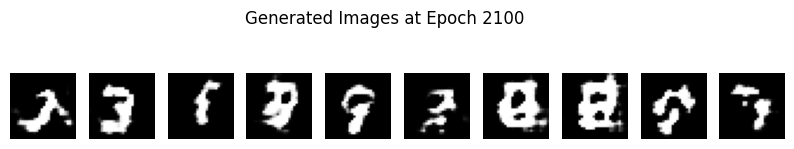

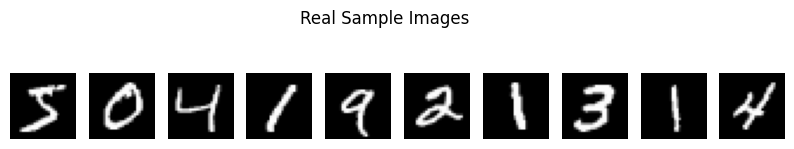

Epoch 2200: D Loss = 0.2356, G Loss = 3.0425


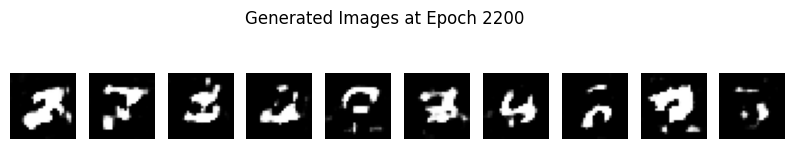

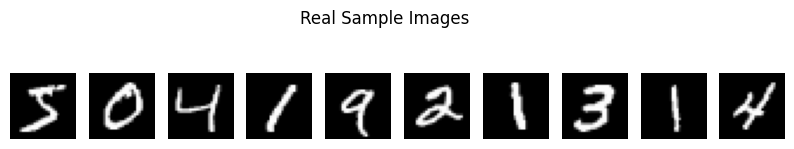

Epoch 2300: D Loss = 0.1210, G Loss = 3.8738


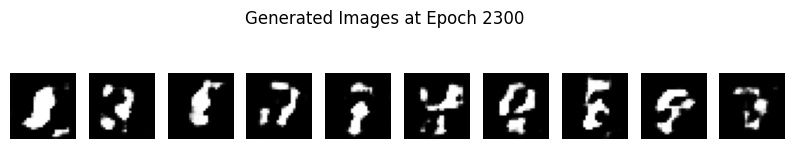

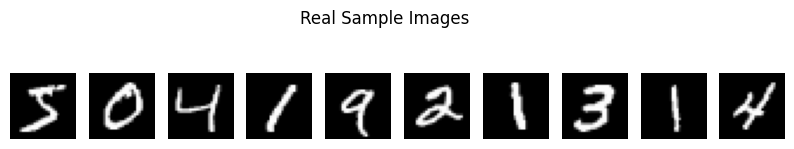

Epoch 2400: D Loss = 0.2931, G Loss = 4.0559


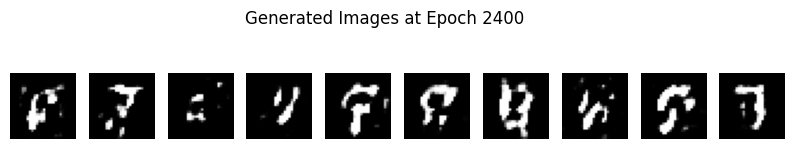

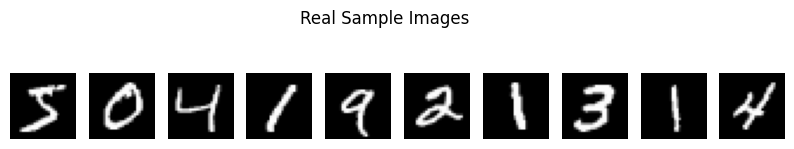

Epoch 2500: D Loss = 0.2536, G Loss = 5.4067


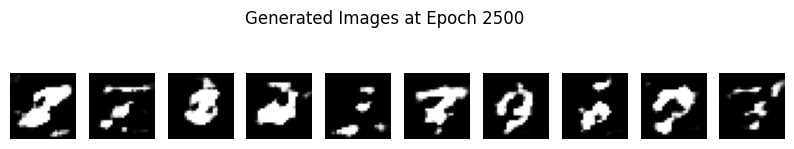

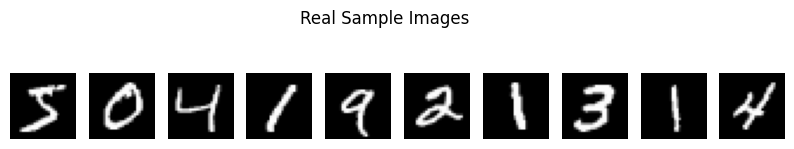

Epoch 2600: D Loss = 0.3045, G Loss = 2.8112


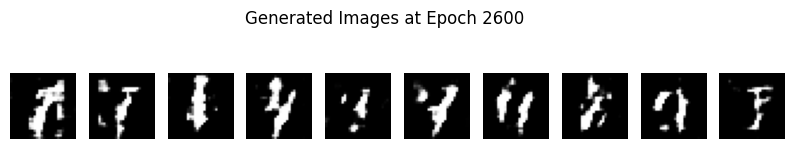

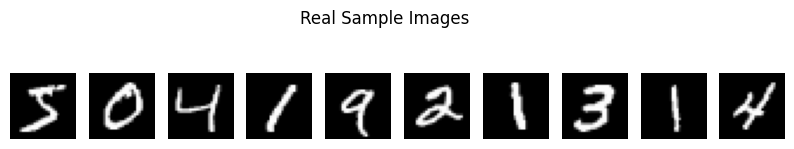

Epoch 2700: D Loss = 0.1791, G Loss = 2.4992


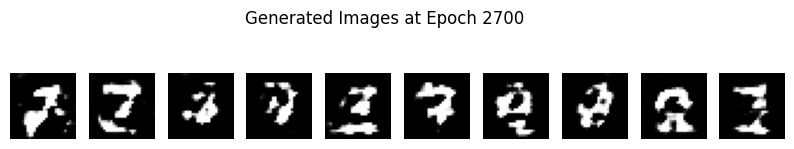

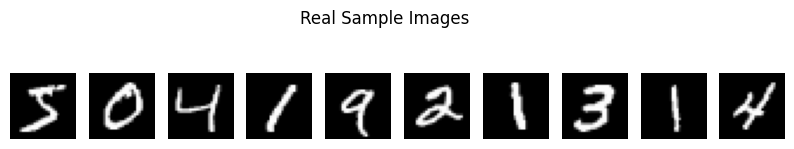

Epoch 2800: D Loss = 0.5361, G Loss = 1.5554


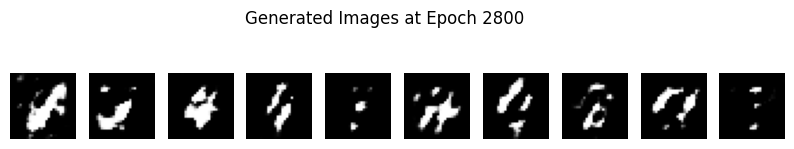

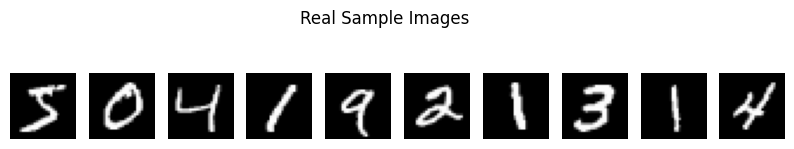

Epoch 2900: D Loss = 0.1959, G Loss = 3.3824


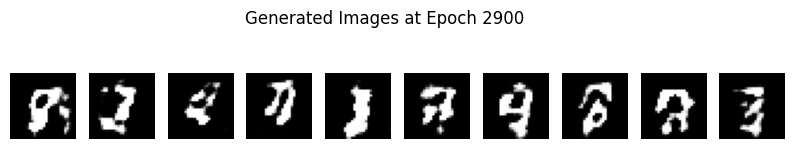

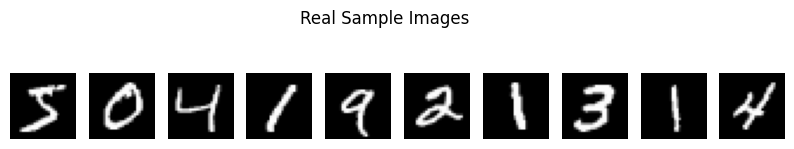

Epoch 3000: D Loss = 0.1987, G Loss = 5.1359


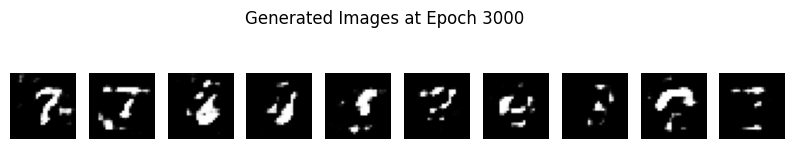

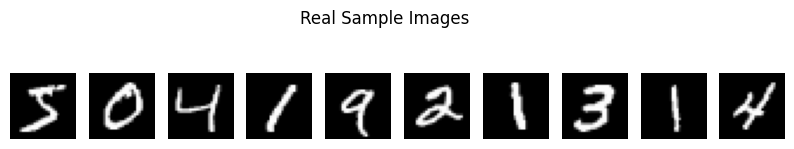

Epoch 3100: D Loss = 0.1380, G Loss = 3.6754


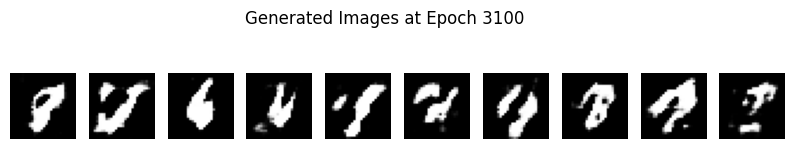

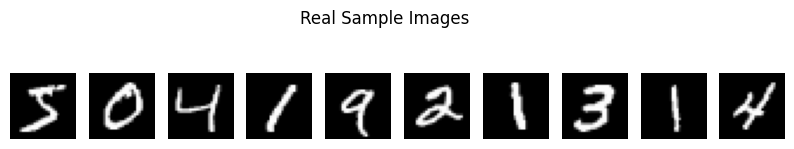

Epoch 3200: D Loss = 0.2025, G Loss = 2.6769


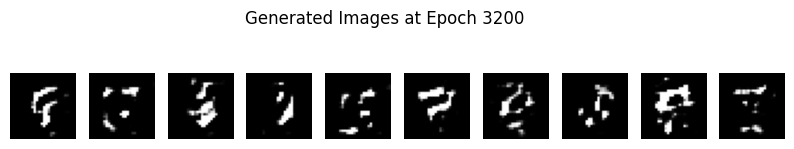

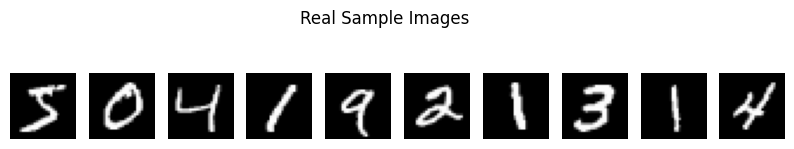

Epoch 3300: D Loss = 0.1380, G Loss = 4.7628


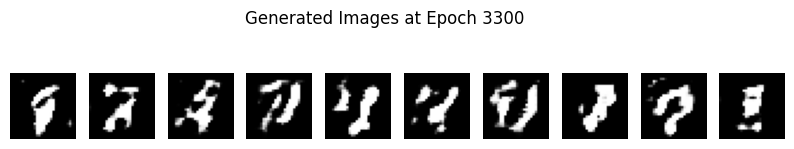

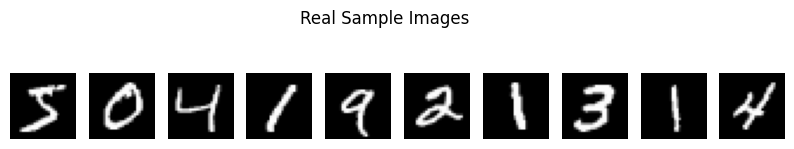

Epoch 3400: D Loss = 0.0900, G Loss = 3.9658


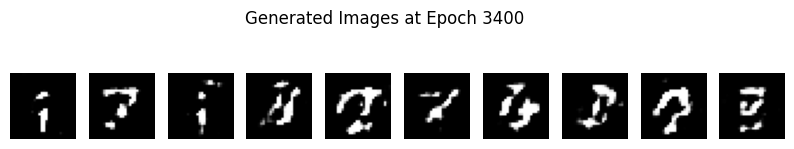

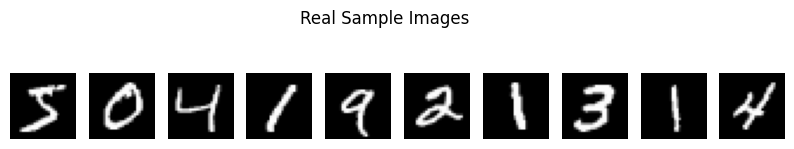

Epoch 3500: D Loss = 0.0828, G Loss = 4.6673


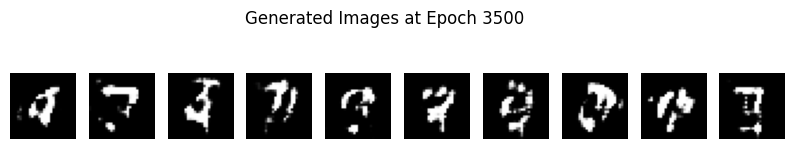

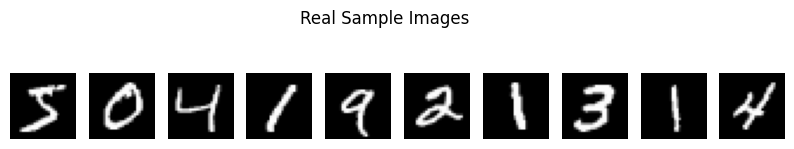

Epoch 3600: D Loss = 0.0774, G Loss = 4.7370


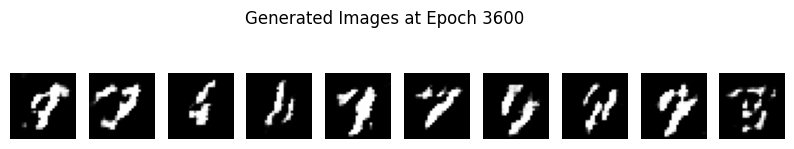

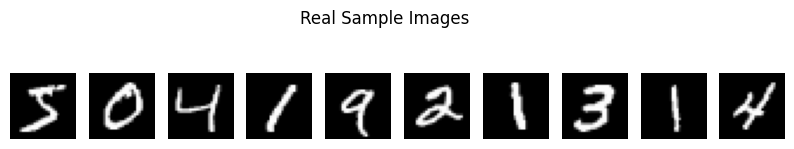

Epoch 3700: D Loss = 0.0769, G Loss = 4.3147


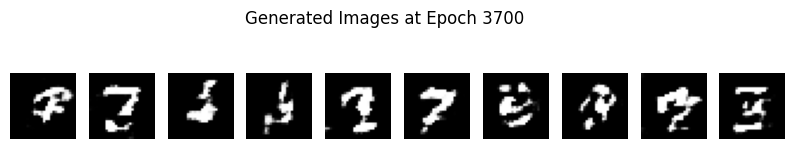

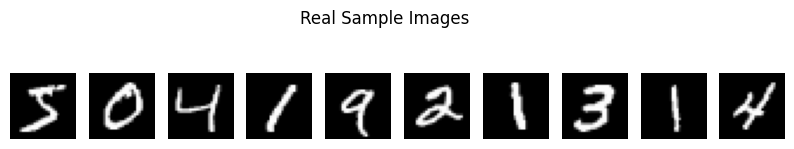

Epoch 3800: D Loss = 0.0396, G Loss = 5.3902


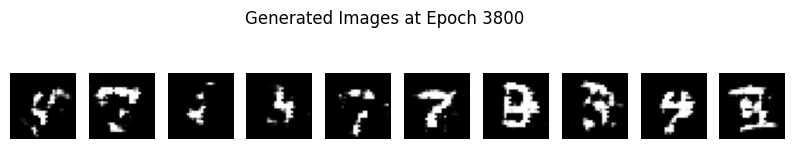

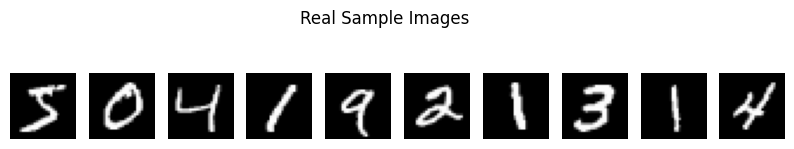

Epoch 3900: D Loss = 0.1038, G Loss = 4.9847


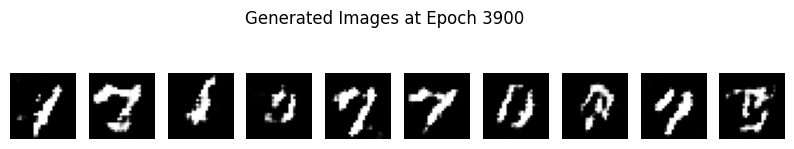

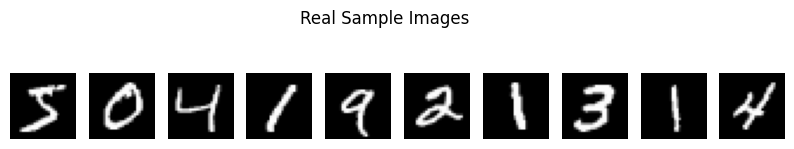

Epoch 4000: D Loss = 0.0695, G Loss = 7.0351


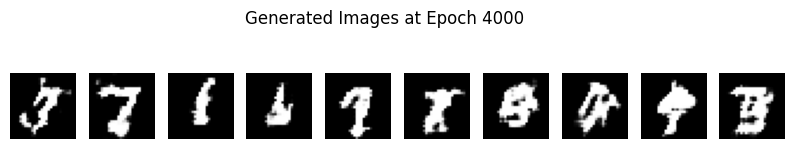

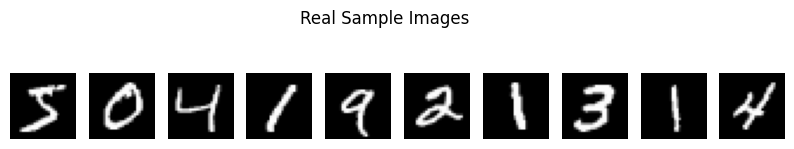

Epoch 4100: D Loss = 0.1016, G Loss = 8.3608


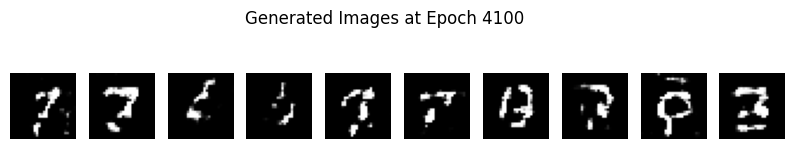

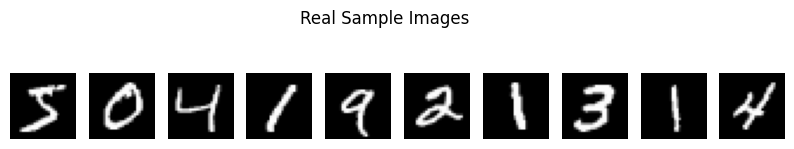

Epoch 4200: D Loss = 0.0429, G Loss = 4.8271


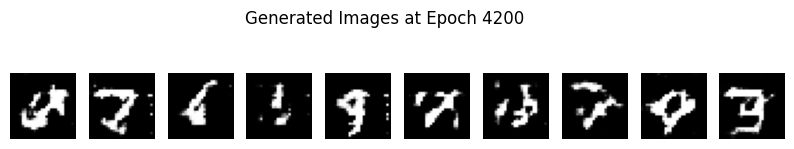

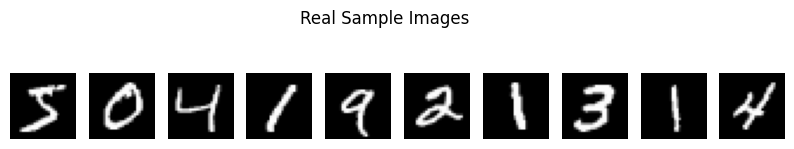

Epoch 4300: D Loss = 0.0493, G Loss = 5.4627


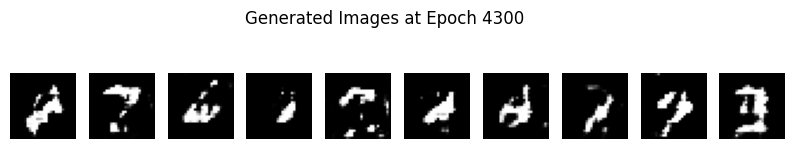

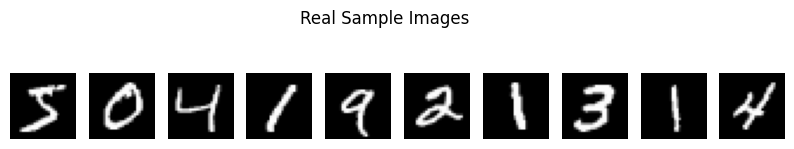

Epoch 4400: D Loss = 0.0693, G Loss = 4.9369


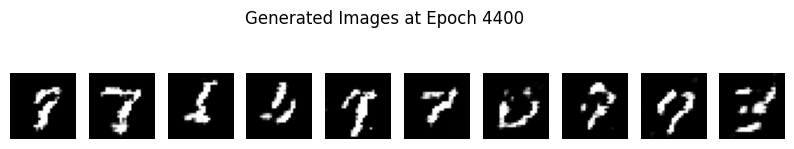

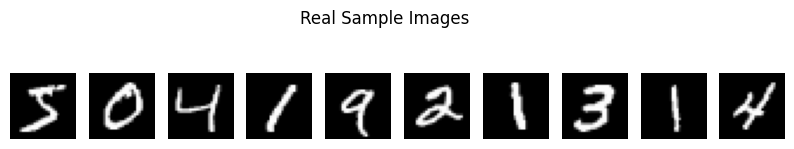

Epoch 4500: D Loss = 0.0873, G Loss = 4.0977


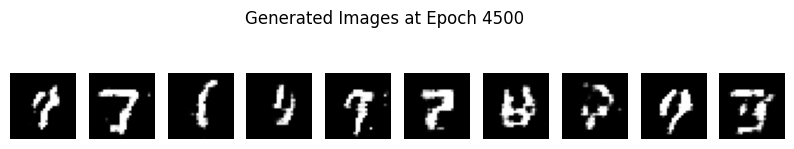

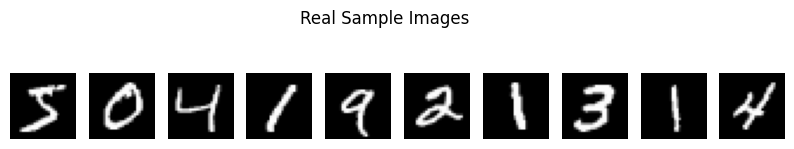

Epoch 4600: D Loss = 0.0871, G Loss = 7.2560


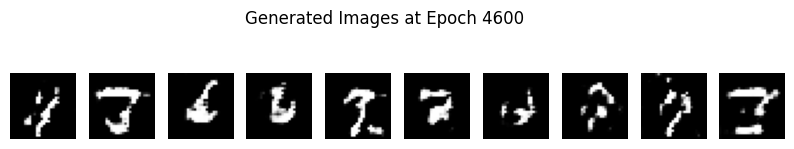

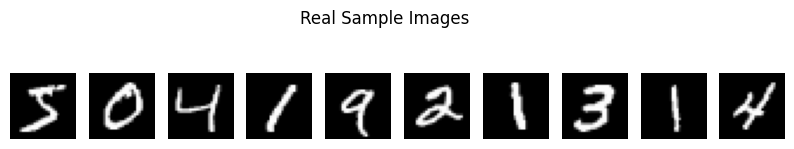

Epoch 4700: D Loss = 0.0939, G Loss = 5.8625


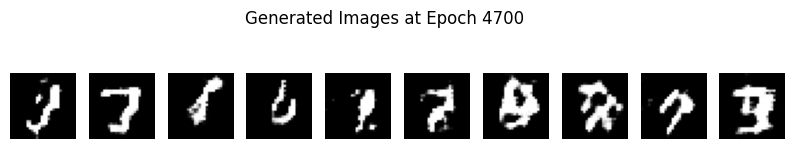

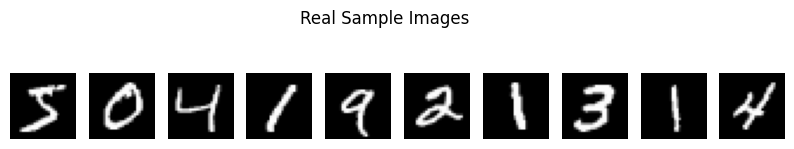

Epoch 4800: D Loss = 0.1552, G Loss = 9.7765


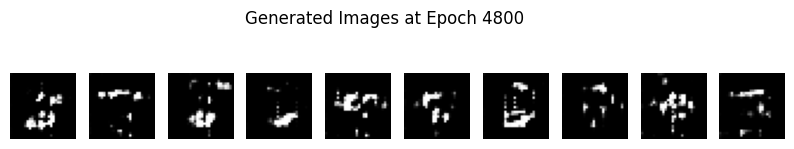

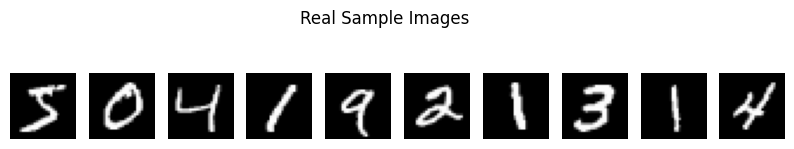

Epoch 4900: D Loss = 0.0392, G Loss = 4.7149


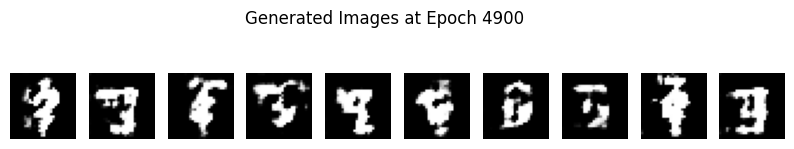

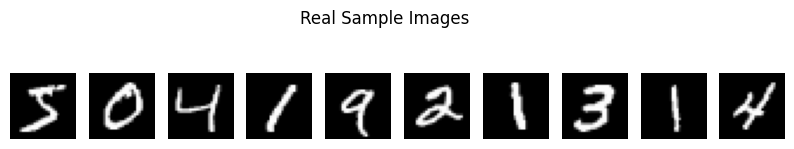

Epoch 5000: D Loss = 0.0972, G Loss = 4.7546


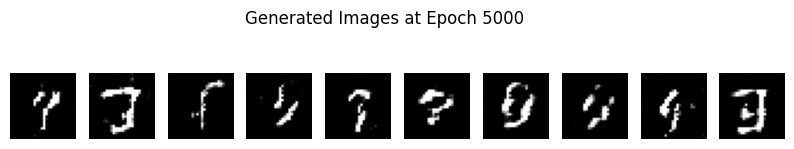

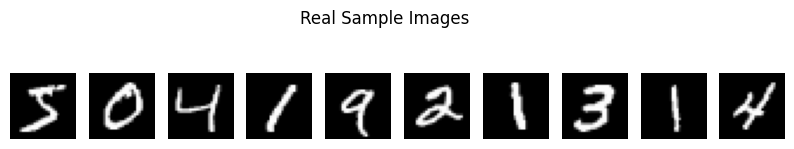

Epoch 5100: D Loss = 0.0352, G Loss = 4.2607


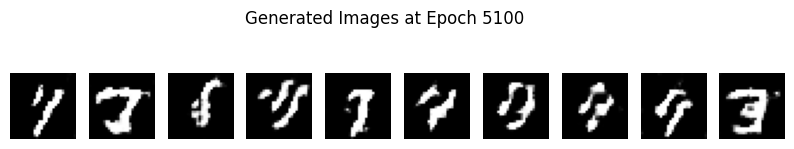

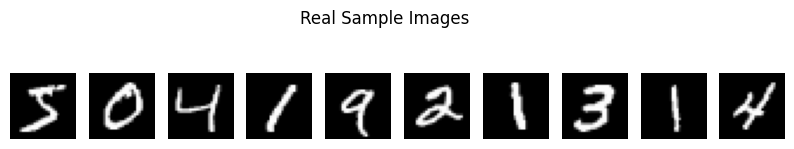

Epoch 5200: D Loss = 0.0670, G Loss = 6.4510


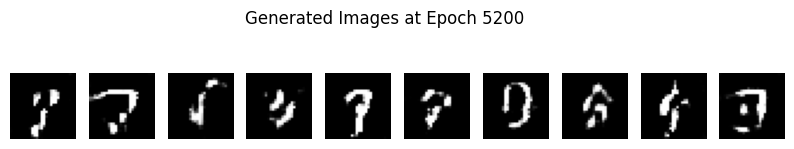

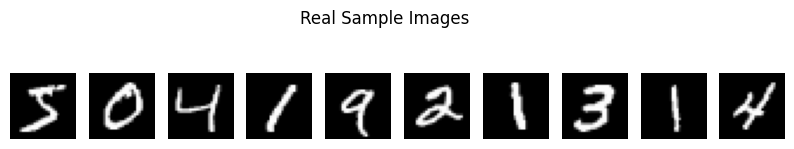

Epoch 5300: D Loss = 0.0373, G Loss = 5.0408


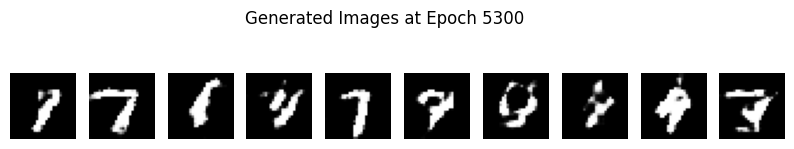

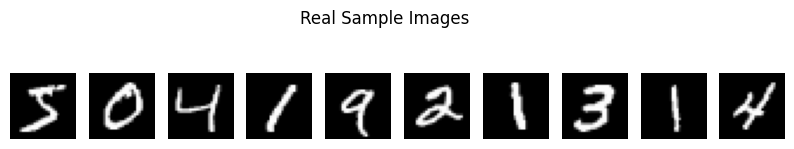

Epoch 5400: D Loss = 0.1294, G Loss = 3.7842


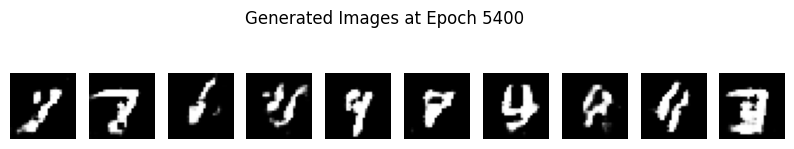

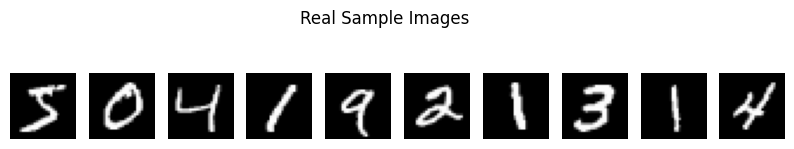

Epoch 5500: D Loss = 0.2100, G Loss = 2.8433


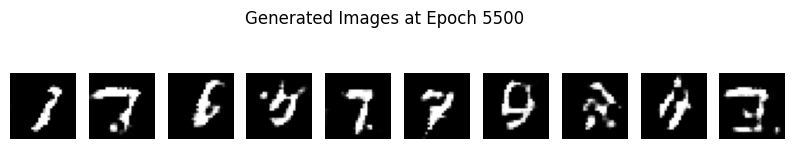

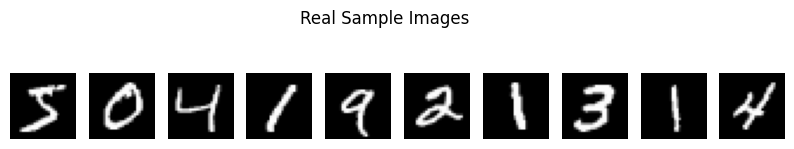

Epoch 5600: D Loss = 0.1150, G Loss = 3.7314


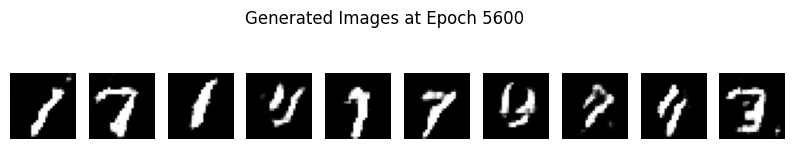

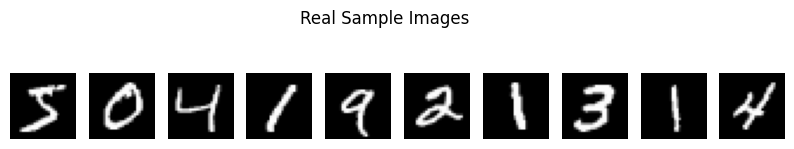

Epoch 5700: D Loss = 0.1647, G Loss = 3.8748


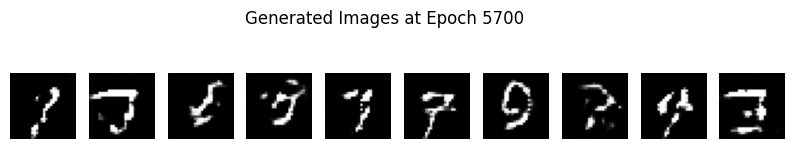

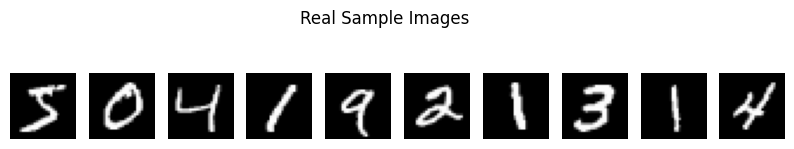

Epoch 5800: D Loss = 0.1645, G Loss = 8.2942


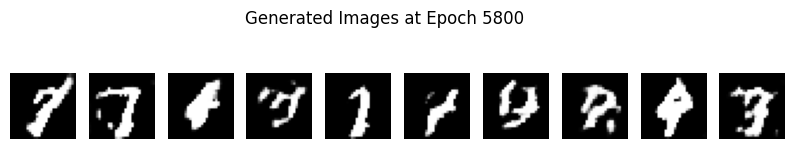

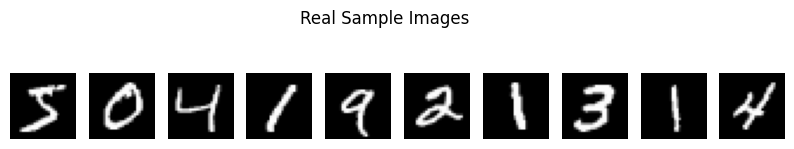

Epoch 5900: D Loss = 0.0983, G Loss = 4.7836


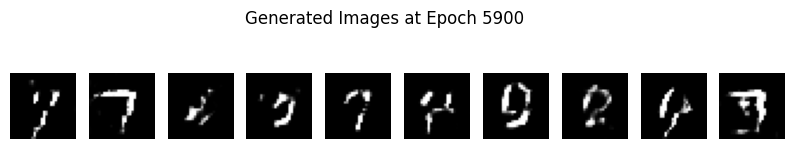

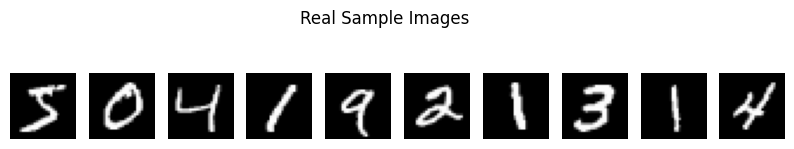

Epoch 6000: D Loss = 0.0422, G Loss = 5.2781


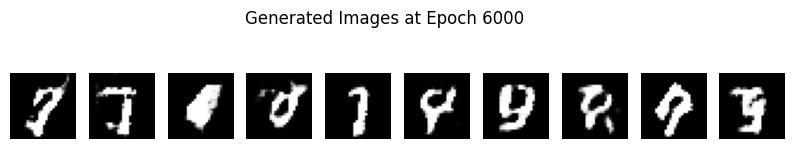

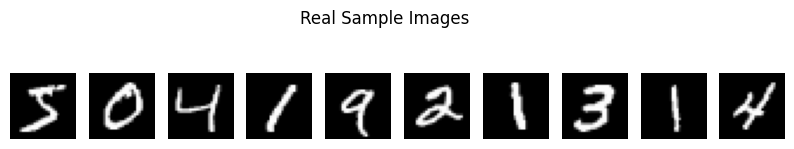

Epoch 6100: D Loss = 0.0501, G Loss = 6.1223


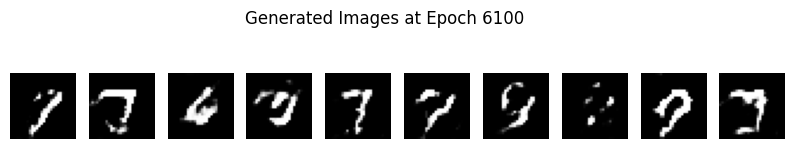

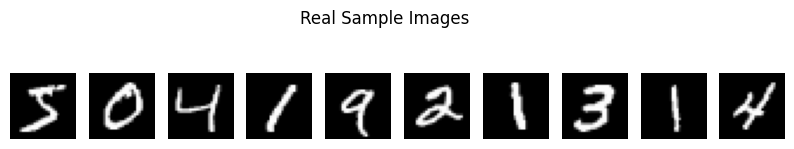

Epoch 6200: D Loss = 0.0467, G Loss = 4.8029


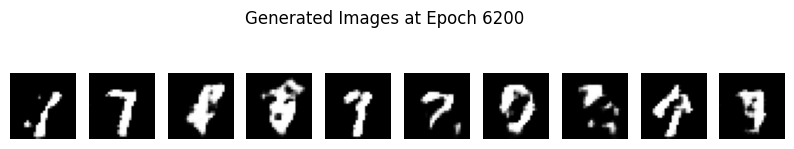

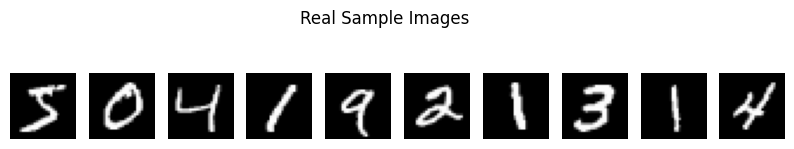

Epoch 6300: D Loss = 0.0824, G Loss = 4.2213


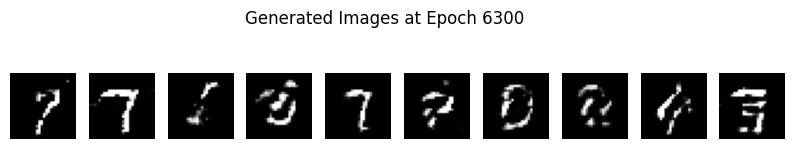

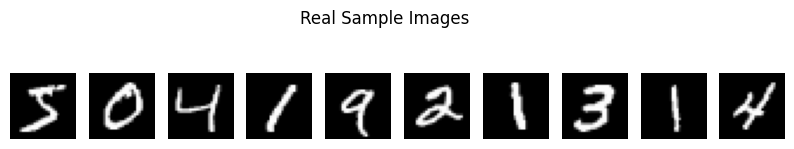

Epoch 6400: D Loss = 0.1287, G Loss = 3.5128


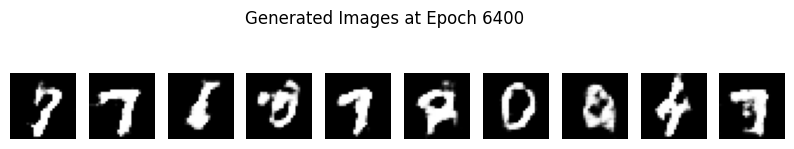

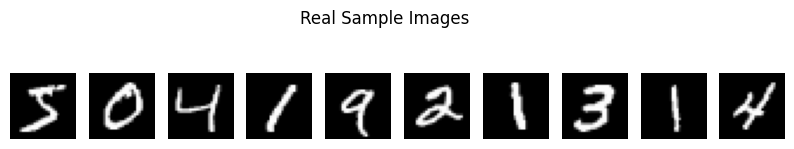

Epoch 6500: D Loss = 0.0922, G Loss = 4.9937


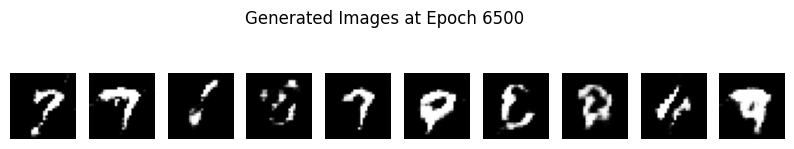

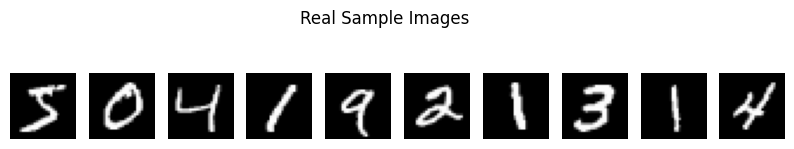

Epoch 6600: D Loss = 0.0524, G Loss = 4.2530


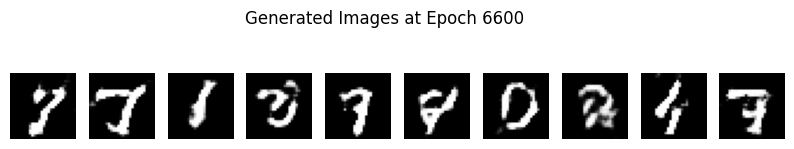

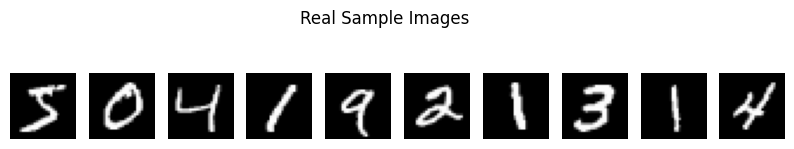

Epoch 6700: D Loss = 0.0540, G Loss = 5.1283


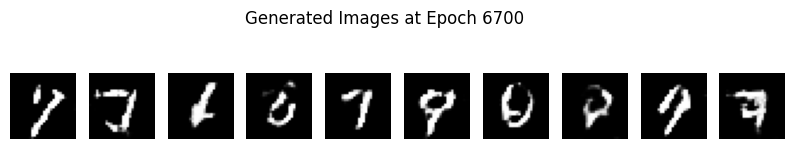

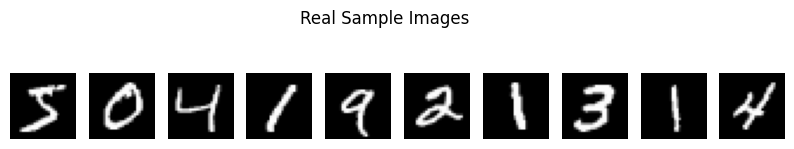

Epoch 6800: D Loss = 0.0831, G Loss = 7.6037


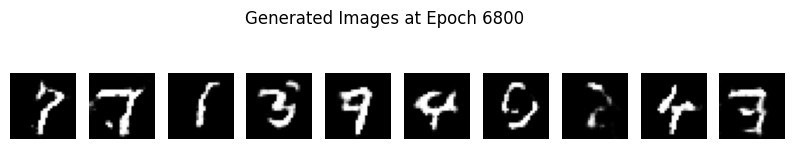

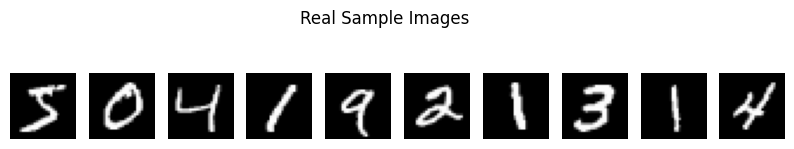

Epoch 6900: D Loss = 0.0890, G Loss = 4.3657


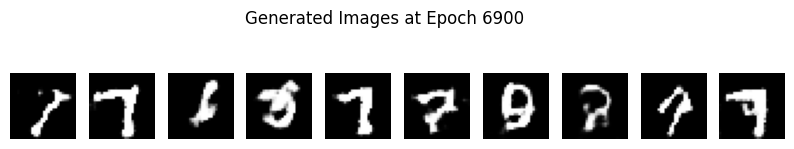

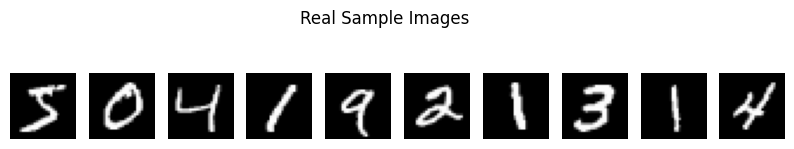

Epoch 7000: D Loss = 0.1249, G Loss = 5.3084


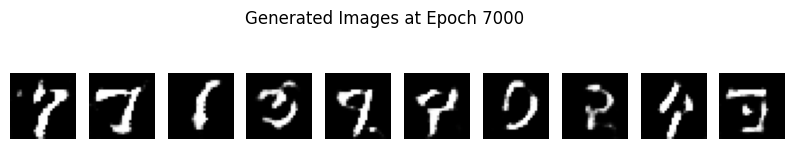

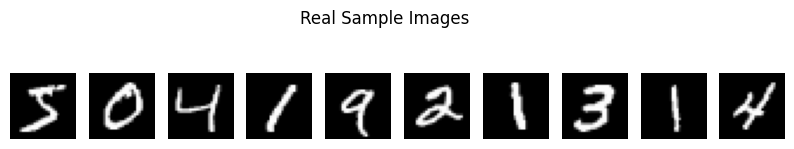

Epoch 7100: D Loss = 0.0372, G Loss = 4.6939


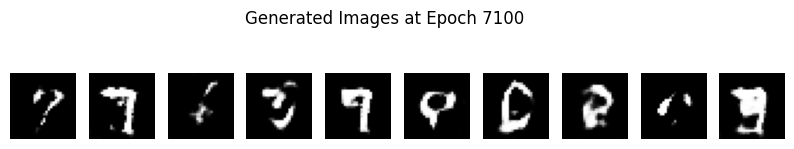

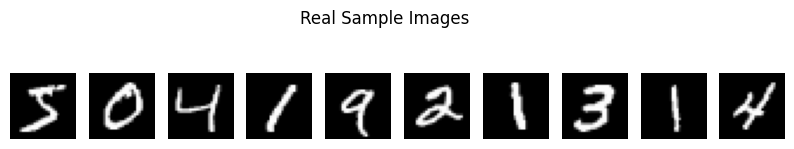

Epoch 7200: D Loss = 0.0227, G Loss = 6.0530


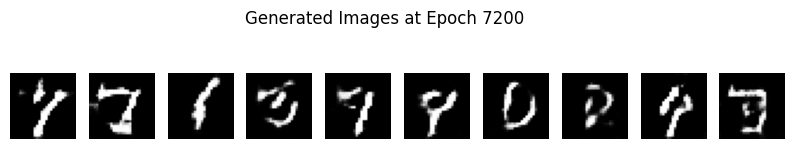

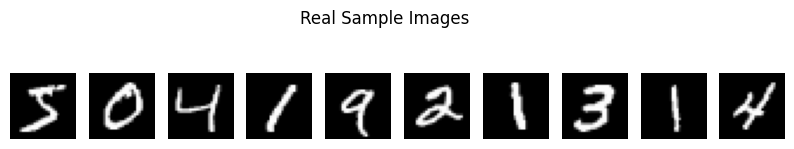

Epoch 7300: D Loss = 0.0821, G Loss = 4.5626


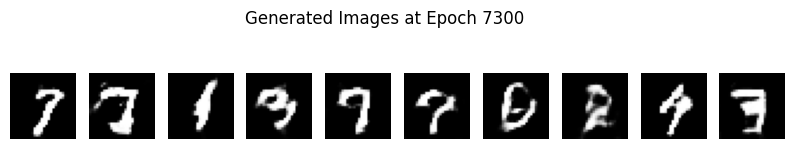

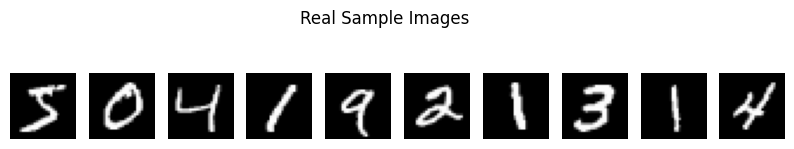

Epoch 7400: D Loss = 0.1109, G Loss = 4.4852


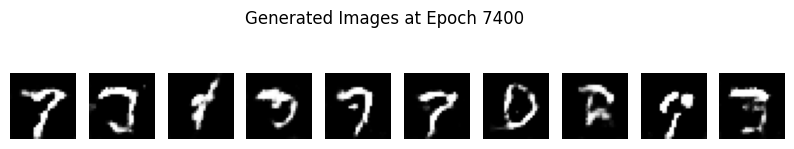

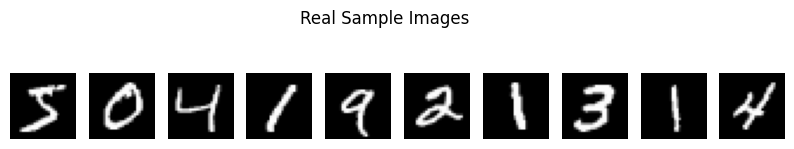

Epoch 7500: D Loss = 0.1142, G Loss = 4.5490


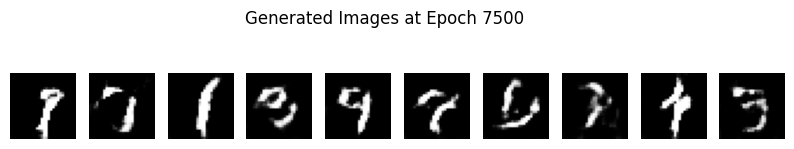

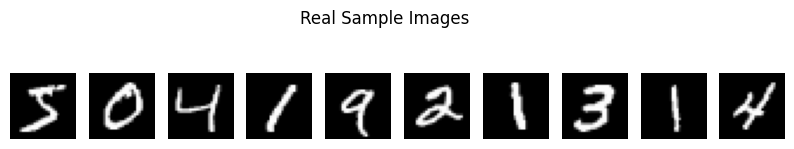

Epoch 7600: D Loss = 0.0236, G Loss = 5.9138


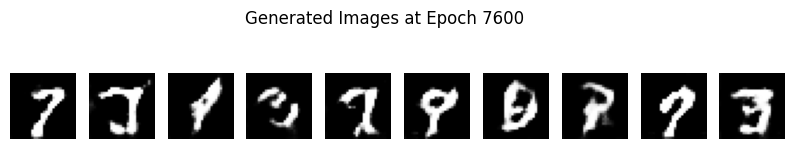

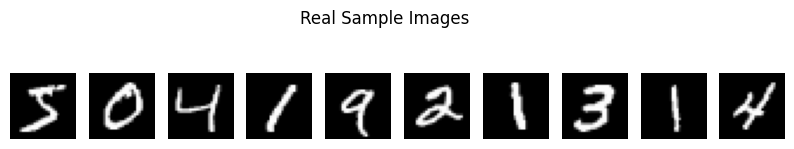

Epoch 7700: D Loss = 0.1226, G Loss = 6.9350


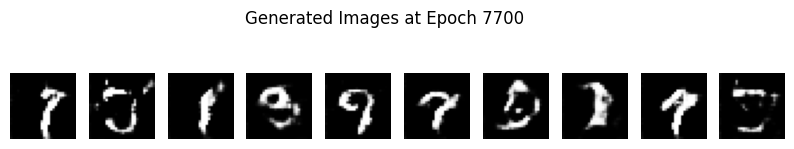

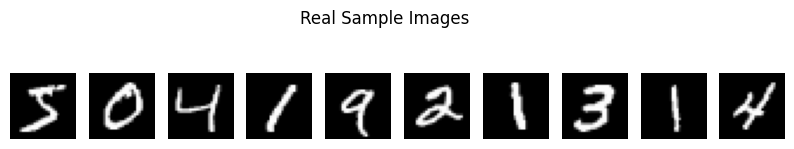

Epoch 7800: D Loss = 1.0147, G Loss = 1.6721


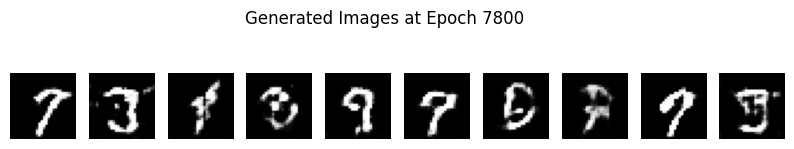

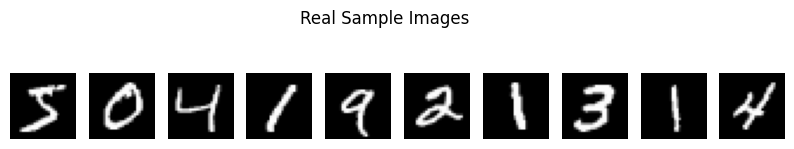

Epoch 7900: D Loss = 0.5201, G Loss = 6.7636


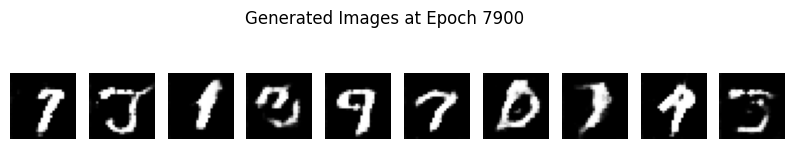

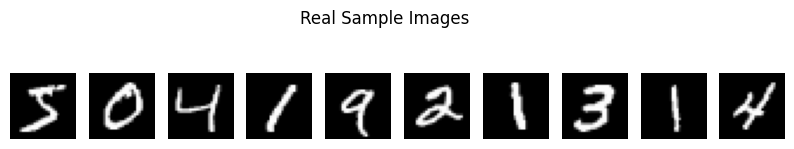

Epoch 8000: D Loss = 0.0652, G Loss = 4.6582


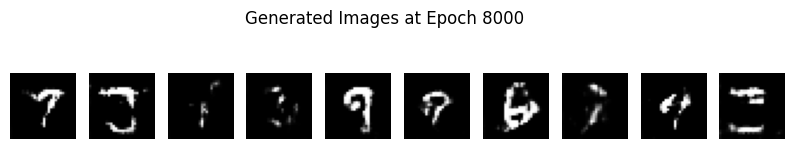

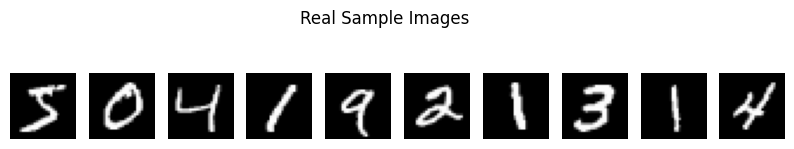

Epoch 8100: D Loss = 0.0951, G Loss = 4.5655


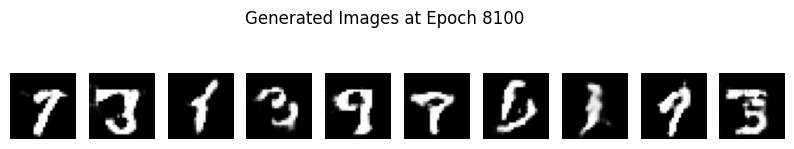

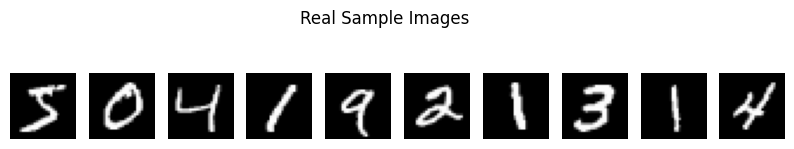

Epoch 8200: D Loss = 0.1085, G Loss = 3.9471


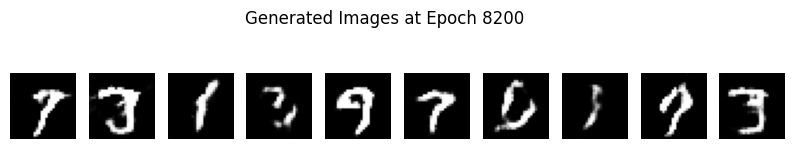

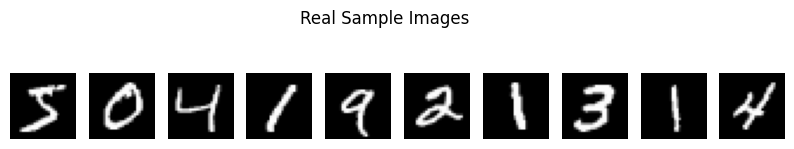

Epoch 8300: D Loss = 0.0913, G Loss = 6.3578


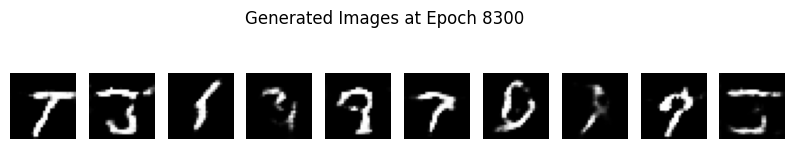

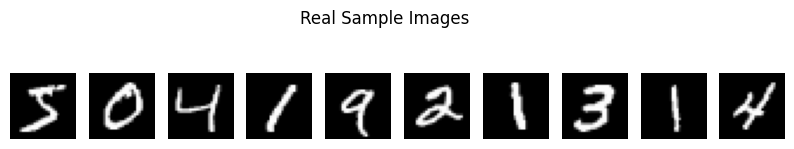

Epoch 8400: D Loss = 0.0872, G Loss = 5.2085


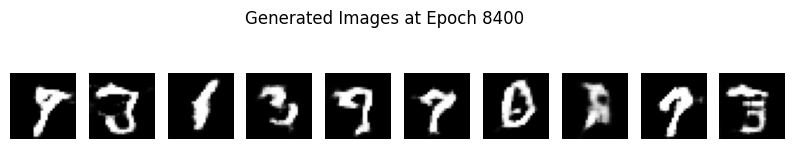

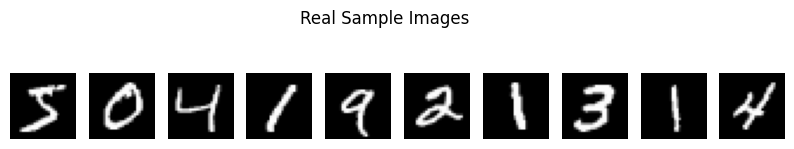

Epoch 8500: D Loss = 0.1480, G Loss = 6.3644


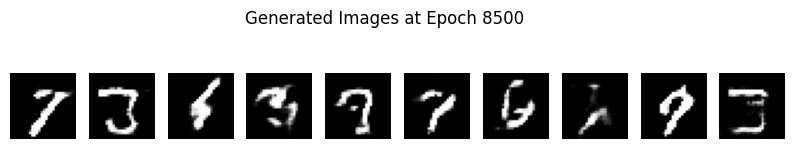

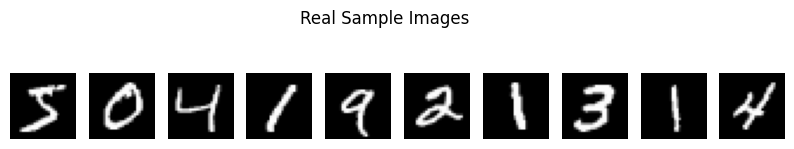

Epoch 8600: D Loss = 0.2437, G Loss = 2.9992


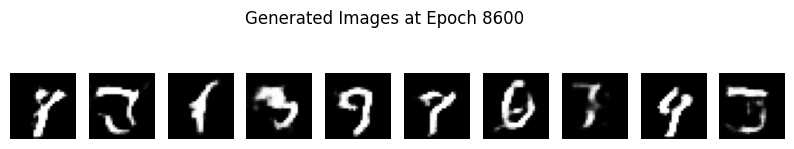

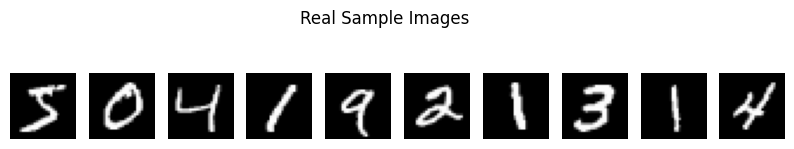

Epoch 8700: D Loss = 0.1220, G Loss = 8.3162


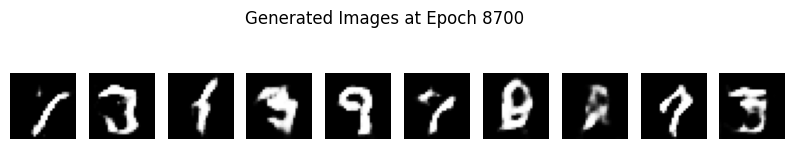

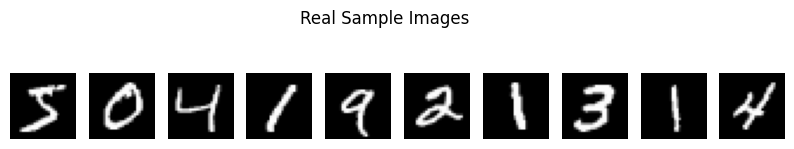

Epoch 8800: D Loss = 0.1043, G Loss = 4.6955


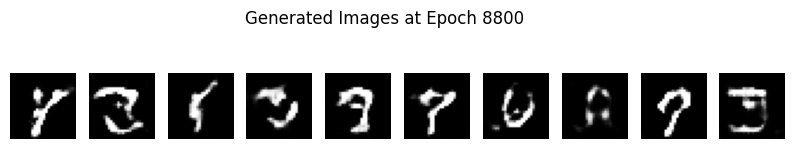

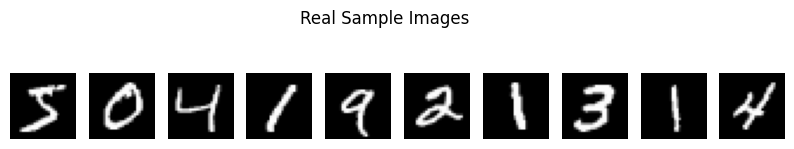

Epoch 8900: D Loss = 0.0801, G Loss = 4.5839


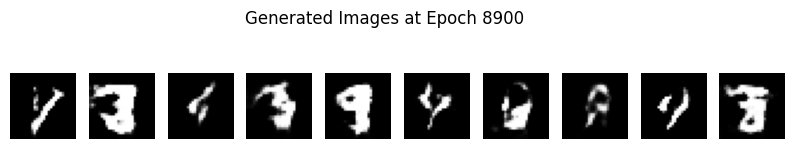

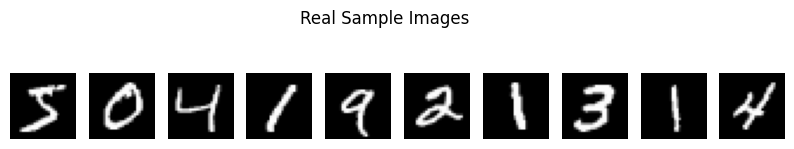

Epoch 9000: D Loss = 0.1278, G Loss = 4.8087


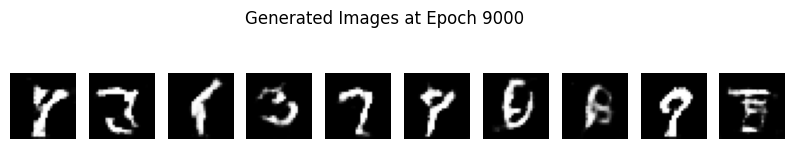

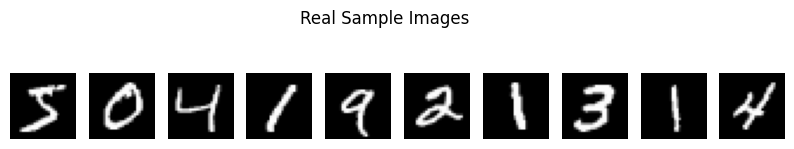

Epoch 9100: D Loss = 0.1788, G Loss = 4.4397


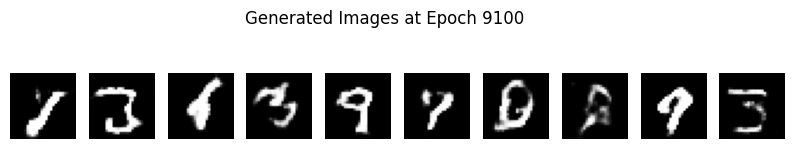

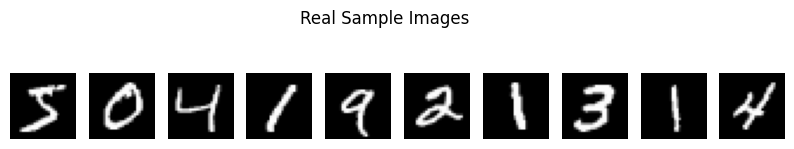

Epoch 9200: D Loss = 0.4608, G Loss = 7.7537


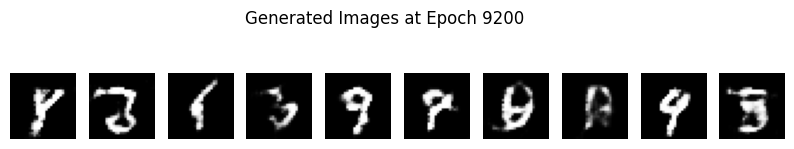

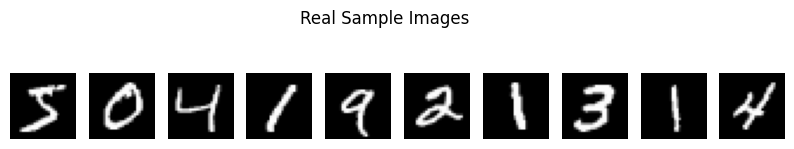

Epoch 9300: D Loss = 0.3774, G Loss = 2.1023


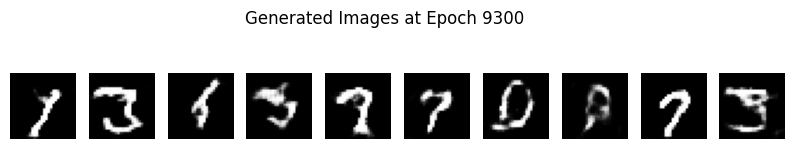

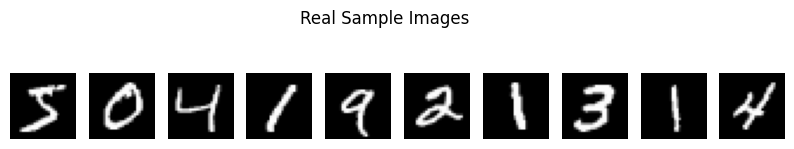

Epoch 9400: D Loss = 0.0853, G Loss = 6.8034


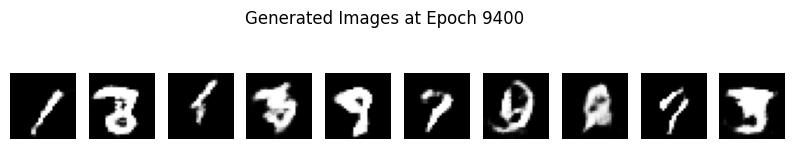

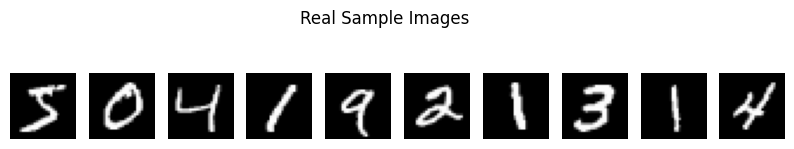

Epoch 9500: D Loss = 0.0876, G Loss = 5.5322


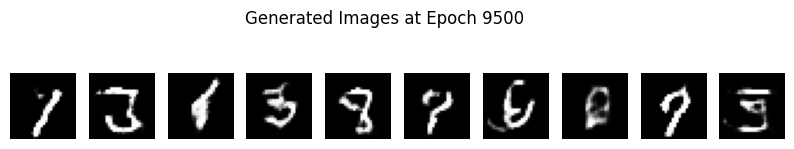

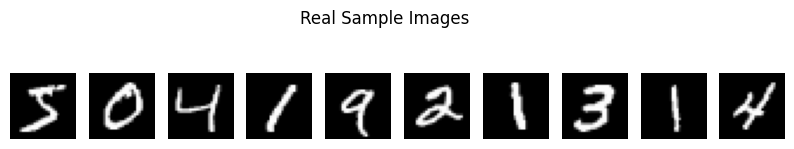

Epoch 9600: D Loss = 0.2214, G Loss = 5.8409


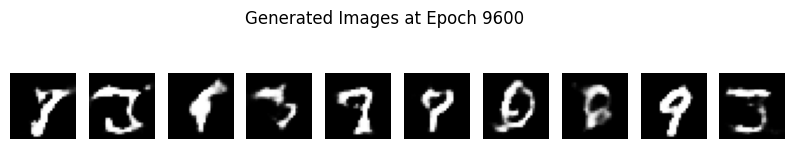

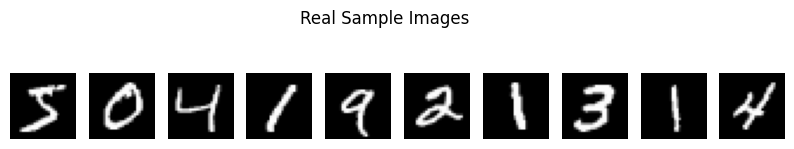

Epoch 9700: D Loss = 0.3393, G Loss = 2.3101


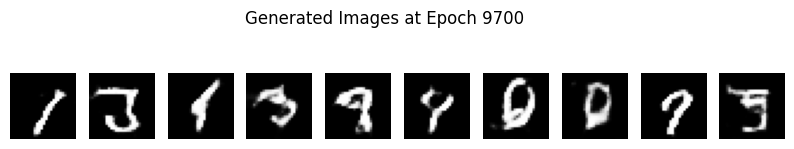

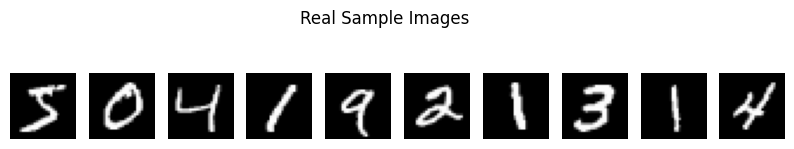

Epoch 9800: D Loss = 0.1185, G Loss = 5.9309


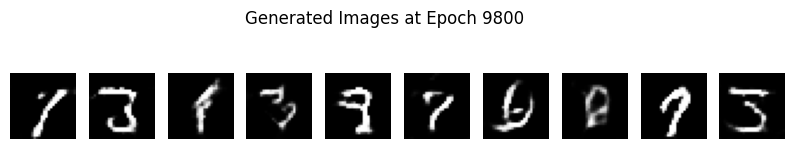

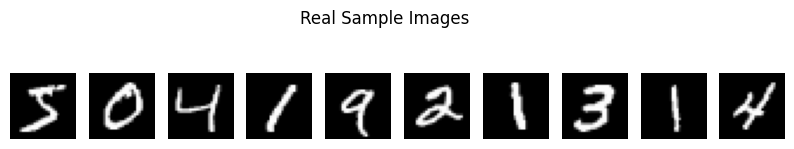

Epoch 9900: D Loss = 0.2307, G Loss = 3.0035


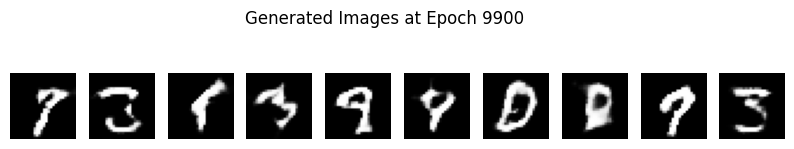

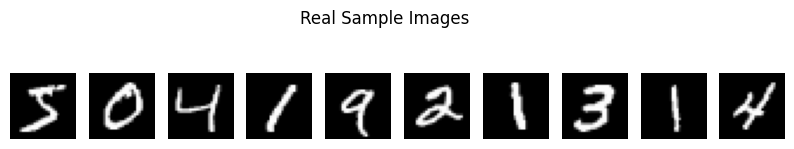

Epoch 10000: D Loss = 0.1468, G Loss = 4.5765


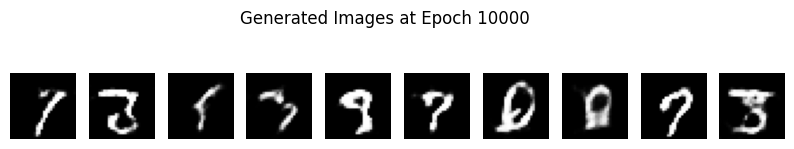

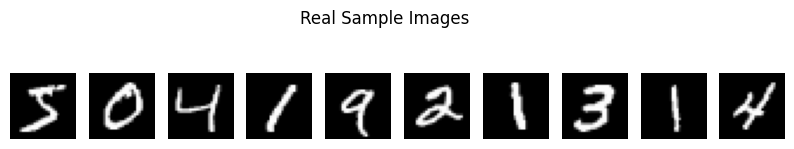

Epoch 10100: D Loss = 0.2687, G Loss = 4.2824


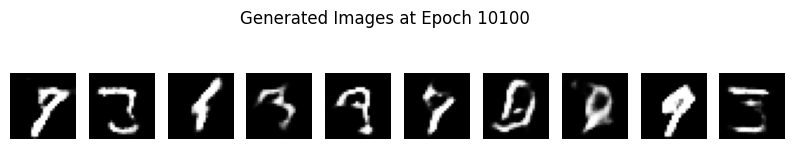

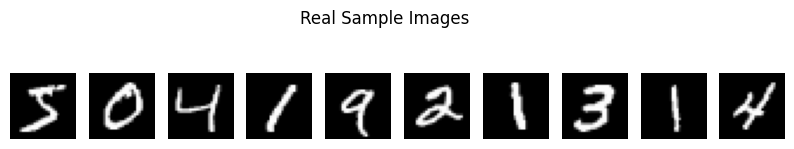

Epoch 10200: D Loss = 0.1167, G Loss = 3.9152


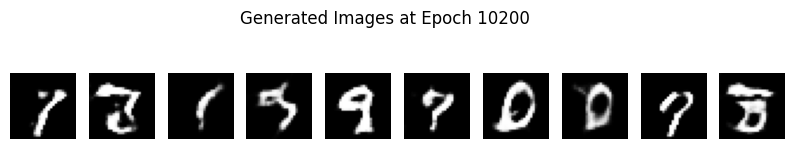

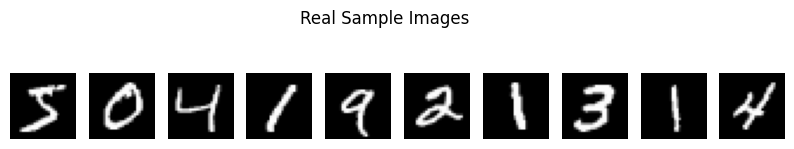

In [ ]:
# ---- Training Loop ----
for epoch in range(epochs):
    x_real, y_real = next(data_iter)
    z = tf.random.normal([batch_size, z_dim])
    y_fake = tf.one_hot(np.random.randint(0, 10, size=batch_size), depth=10, dtype=tf.float32)

    with tf.GradientTape() as d_tape, tf.GradientTape() as g_tape:
        x_fake = G([z, y_fake], training=True)

        d_loss = D_loss(D, x_real, x_fake, y_fake)
        g_loss = G_loss(D, x_fake, y_fake)

    d_grads = d_tape.gradient(d_loss, D.trainable_variables)
    g_grads = g_tape.gradient(g_loss, G.trainable_variables)
    D_opt.apply_gradients(zip(d_grads, D.trainable_variables))
    G_opt.apply_gradients(zip(g_grads, G.trainable_variables))

    d_losses.append(d_loss.numpy())
    g_losses.append(g_loss.numpy())

    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss = {d_loss.numpy():.4f}, G Loss = {g_loss.numpy():.4f}")
        visualize_images(G, z_vis, y_vis, title=f"Generated Images at Epoch {epoch}")

        # Show real samples for comparison
        plt.figure(figsize=(10, 2))
        for i in range(10):
            plt.subplot(1, 10, i + 1)
            plt.imshow(x_train[i], cmap='gray')
            plt.axis('off')
        plt.suptitle("Real Sample Images")
        plt.show()

In [1]:
# ---- Final Loss Curves ----
plot_losses(d_losses, g_losses)

NameError: name 'plot_losses' is not defined